[*********************100%***********************]  1 of 1 completed


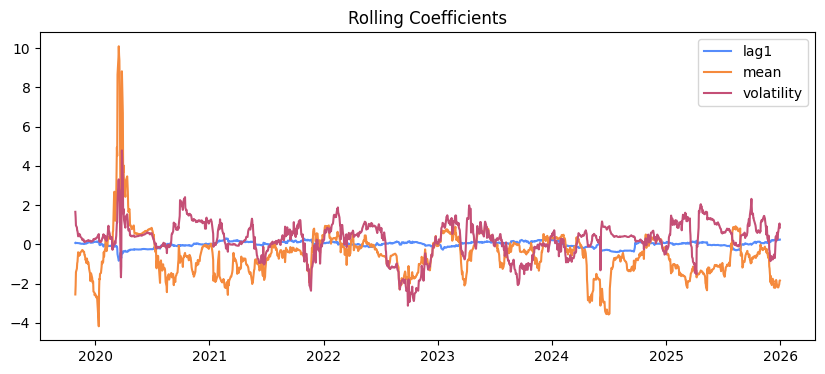

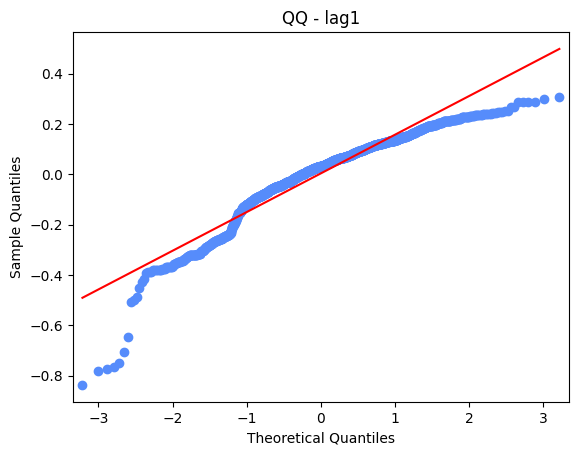

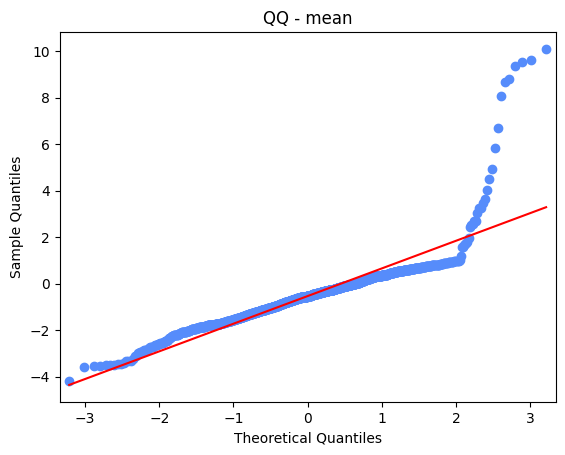

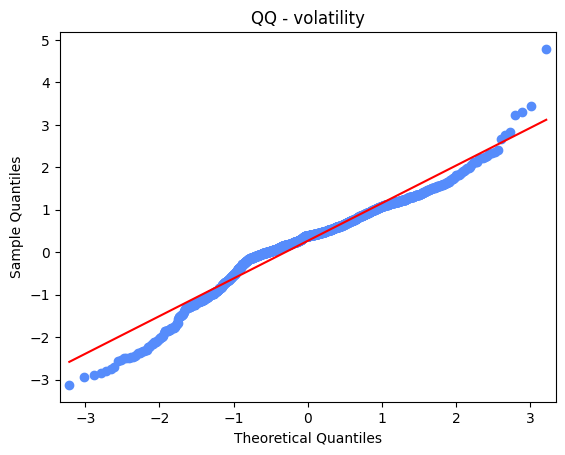

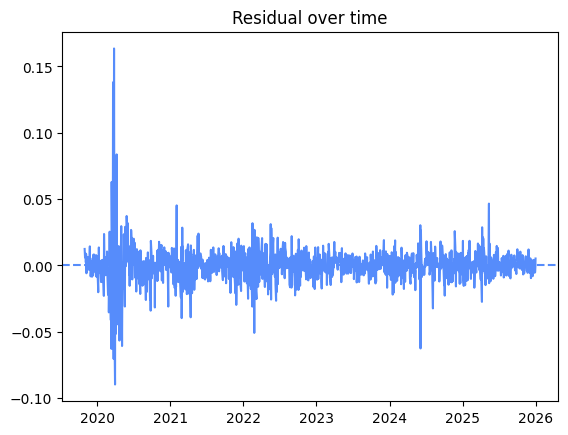

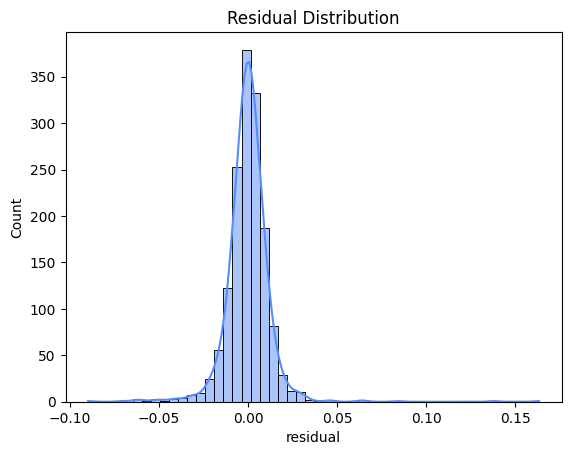

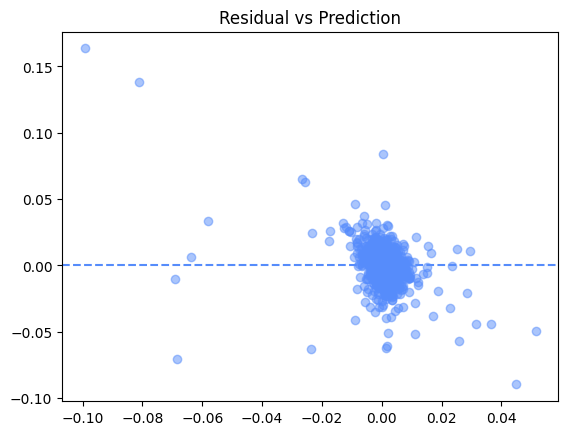

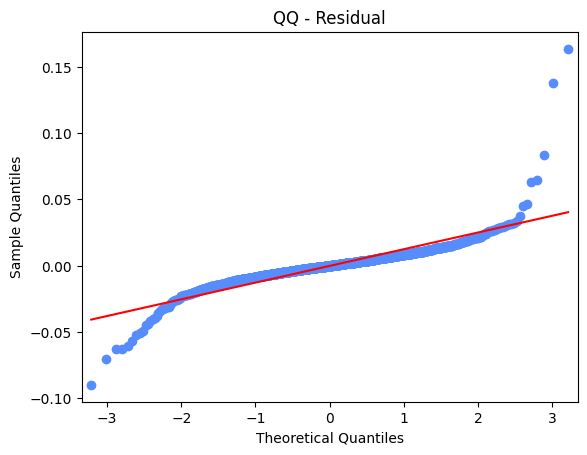

Residual mean: -6.410652246811878e-05


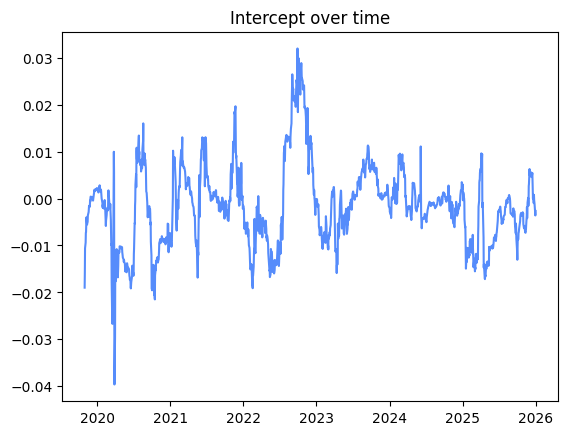

In [1]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm


# -------------------------------
# 2. DOWNLOAD DATA
# -------------------------------

# Get NIFTY 50 data
df = yf.download("^NSEI",
                 start="2019-06-06",
                 end="2026-01-01",
                 auto_adjust=False,
                 multi_level_index=False)

# Keep only adjusted close
df = df[['Adj Close']]


# -------------------------------
# 3. FEATURE ENGINEERING
# -------------------------------

# Log returns → more stable for modeling
df['returns'] = np.log(df['Adj Close'] / df['Adj Close'].shift(1))

# Lagged return (yesterday's return)
df['lag1'] = df['returns'].shift(1)

# Rolling mean → short-term trend (shift to avoid leakage)
df['ma_20'] = df['returns'].rolling(20).mean().shift(1)

# Rolling volatility → risk measure (shift to avoid leakage)
df['volatility_20'] = df['returns'].rolling(20).std().shift(1)

# Drop NaNs caused by rolling/shift
df.dropna(inplace=True)


# -------------------------------
# 4. DEFINE FEATURES & TARGET
# -------------------------------

X = df[['lag1', 'ma_20', 'volatility_20']]   # inputs
y = df['returns']                           # target


# -------------------------------
# 5. ROLLING REGRESSION
# -------------------------------

window = 75   # training window size

coef = []       # store coefficients
pred = []       # predictions
intercept = []  # intercept values
dates = []      # timestamps

for i in range(window, len(df)):

    # Train on past window
    X_train = X.iloc[i-window:i]
    y_train = y.iloc[i-window:i]

    # Predict next point
    X_test = X.iloc[i:i+1]

    # Fit model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Predict next return
    forecast = model.predict(X_test)[0]

    # Store outputs
    pred.append(forecast)
    coef.append(model.coef_)
    intercept.append(model.intercept_)
    dates.append(X_test.index[0])


# -------------------------------
# 6. STORE RESULTS
# -------------------------------

coef_arr = np.array(coef)

results = pd.DataFrame({
    "prediction": pred,
    "coef_lag1": coef_arr[:, 0],
    "coef_mean": coef_arr[:, 1],
    "coef_std": coef_arr[:, 2],
    "intercept": intercept
}, index=dates)

# Add actual returns
results['actual'] = df.loc[results.index, 'returns']

# Residual = error = mispricing
results['residual'] = results['actual'] - results['prediction']

# Reorder
results = results[['actual','prediction','residual',
                   'coef_lag1','coef_mean','coef_std','intercept']]


# -------------------------------
# 7. COEFFICIENT ANALYSIS
# -------------------------------

# Track how each factor evolves over time
plt.figure(figsize=(10,4))
plt.plot(results['coef_lag1'], label='lag1')
plt.plot(results['coef_mean'], label='mean')
plt.plot(results['coef_std'], label='volatility')
plt.legend()
plt.title("Rolling Coefficients")
plt.show()


# Distribution of coefficients
sm.qqplot(results['coef_lag1'], line='s')
plt.title("QQ - lag1")
plt.show()

sm.qqplot(results['coef_mean'], line='s')
plt.title("QQ - mean")
plt.show()

sm.qqplot(results['coef_std'], line='s')
plt.title("QQ - volatility")
plt.show()


# -------------------------------
# 8. RESIDUAL ANALYSIS
# -------------------------------

# Residual over time
plt.plot(results['residual'])
plt.axhline(0, linestyle='--')
plt.title("Residual over time")
plt.show()

# Distribution
sns.histplot(results['residual'], kde=True, bins=50)
plt.title("Residual Distribution")
plt.show()

# Residual vs prediction (should be random)
plt.scatter(results['prediction'], results['residual'], alpha=0.5)
plt.axhline(0, linestyle='--')
plt.title("Residual vs Prediction")
plt.show()

# QQ plot (normality check)
sm.qqplot(results['residual'], line='s')
plt.title("QQ - Residual")
plt.show()

# Mean of residual (should be near zero)
print("Residual mean:", results['residual'].mean())


# -------------------------------
# 9. INTERCEPT ANALYSIS
# -------------------------------

plt.plot(results['intercept'])
plt.title("Intercept over time")
plt.show()

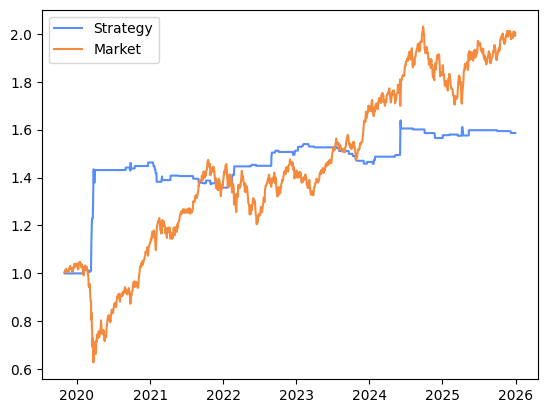

In [2]:
# Convert residual into trading signal

mean = results['residual'].rolling(50).mean()
std = results['residual'].rolling(50).std()

z = (results['residual'] - mean) / std
results['z'] = z

# Trading rule
signal = np.where(z > 2, -1,
         np.where(z < -2, 1, 0))

strategy = pd.Series(signal, index=results.index).shift(1) * results['actual']

cum = (1 + strategy).cumprod()

plt.plot(cum, label='Strategy')
plt.plot((1 + results['actual']).cumprod(), label='Market')
plt.legend()
plt.show()